# The Colour of 5 A.M. — Anime Movie Maker

Before you press **Run All**, check the right-hand panel:

1. **Session options → Accelerator:** `GPU T4 x2`
2. **Session options → Internet:** On (needs a phone-verified Kaggle account)
3. **Input:** your `AnimeMovieMaker` dataset is added

What this makes, the way TV anime is animated:
- a **reference portrait** per character, so their faces match in every picture
- one **picture per shot**, then extra drawings for it: **closed eyes** (blinks), **open mouths** (talking in time with the voices), and the **background without the characters**, so characters and background move separately

The whole movie uses roughly 2–3 GPU hours. Try a few scenes first with `SCENES = "4,5,10"` below.

In [1]:
SCENES = "4,5,10"          # "" = the whole movie. Quick test: "4,5,10"
MAKE_CLIPS = False   # experimental AI video clips instead of drawings (not recommended, faces can melt)

## 1. Setup

In [2]:
import glob, os, shutil, urllib.request
try:
    urllib.request.urlopen('https://huggingface.co', timeout=15)
except Exception:
    raise RuntimeError("No internet in this notebook. Right panel: Session options -> Internet -> On "
                       "(needs a phone-verified account), then Run All again.")
found = glob.glob('/kaggle/input/**/make_movie.py', recursive=True)
assert found, "Add your AnimeMovieMaker dataset first: 'Add Input' in the right panel."
if len(found) > 1:
    print('Warning: more than one copy of the project is attached, using', found[0])
APP = '/kaggle/working/AnimeMovieMaker'
# always refresh the code from the dataset; pictures and drawings made earlier are kept
shutil.copytree(os.path.dirname(found[0]), APP, dirs_exist_ok=True)
os.chdir(APP)
sc = f"--scenes {SCENES}" if SCENES else ""
# Kokoro (voices) needs Python 3.12, so it gets its own environment in the Voices step
!grep -v kokoro requirements-gpu.txt > /tmp/req-gpu.txt && pip install -q -r /tmp/req-gpu.txt
!apt-get -qq install -y espeak-ng > /dev/null 2>&1
!nvidia-smi --query-gpu=index,name,memory.total --format=csv

index, name, memory.total [MiB]
0, Tesla T4, 15360 MiB
1, Tesla T4, 15360 MiB


## 2. Download the models
Animagine XL (about 7 GB) and IP-Adapter, which keeps the characters looking like their reference portraits.

In [3]:
from diffusers import AutoencoderKL, DiffusionPipeline
from huggingface_hub import snapshot_download
try:
    DiffusionPipeline.download("cagliostrolab/animagine-xl-4.0", use_safetensors=True)
except TypeError:
    DiffusionPipeline.download("cagliostrolab/animagine-xl-4.0")
AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix")
snapshot_download("h94/IP-Adapter", allow_patterns=["models/image_encoder/*", "sdxl_models/ip-adapter-plus_sdxl_vit-h.safetensors"])
print("models ready")

model_index.json:   0%|          | 0.00/671 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B /  335MB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

models ready


## 3. Character reference portraits
Four candidates per character; the first one (gold frame) is used.

==> log_refs0.txt <==
  [2/4] kai #1 (22s)
  [3/4] kai #2 (23s)
  [4/4] kai #3 (24s)

==> log_refs1.txt <==
[refs] gpu 1, shard 1/2: 0 portraits to make
[refs] gpu 0, shard 0/1: 0 portraits to make
Portraits -> /kaggle/working/AnimeMovieMaker/output/refs/refs_sheet.jpg


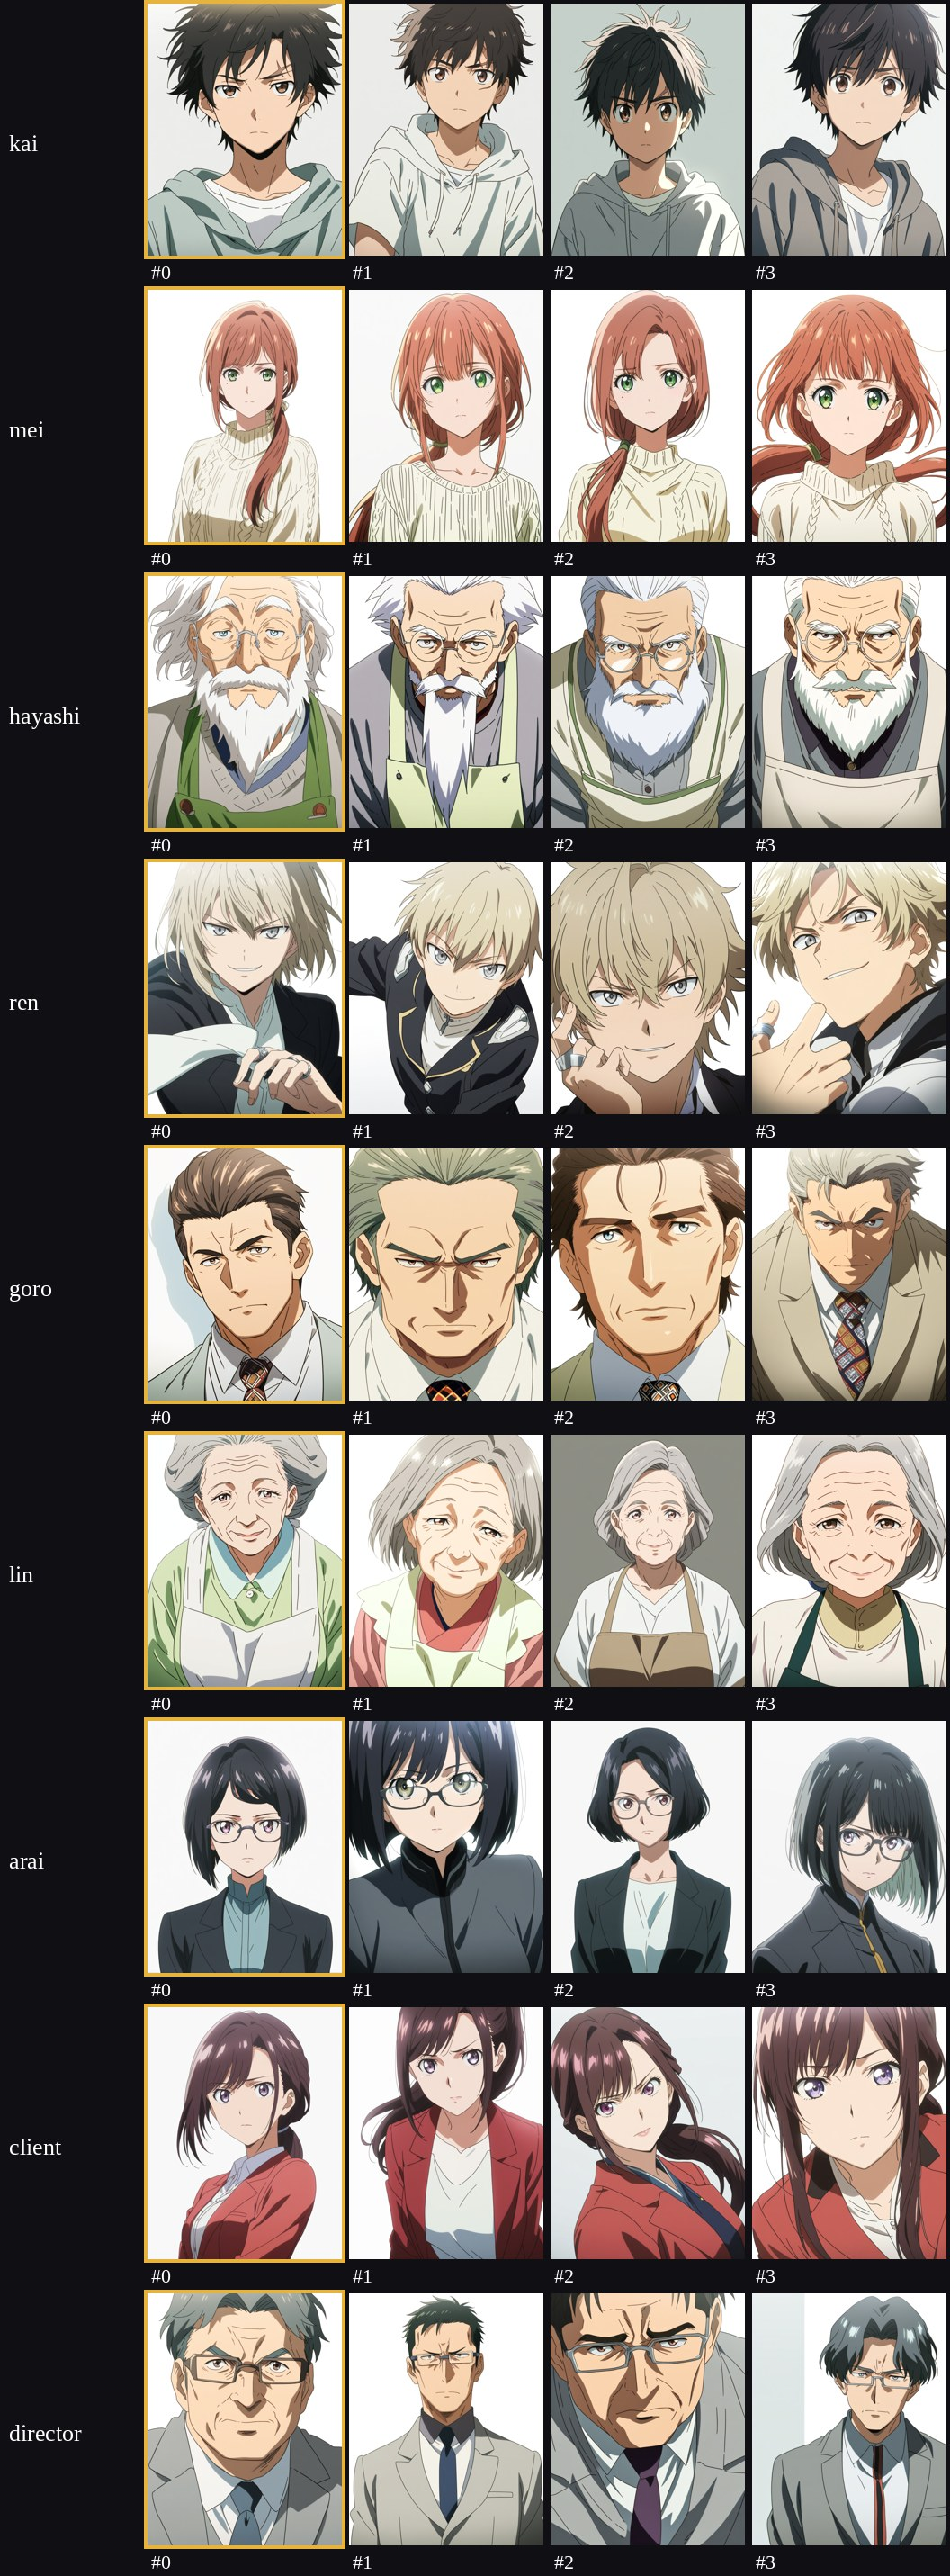

In [4]:
!python make_movie.py refs --gpu 0 --shard 0/2 > log_refs0.txt 2>&1 & python make_movie.py refs --gpu 1 --shard 1/2 > log_refs1.txt 2>&1 ; wait
!tail -n 3 log_refs0.txt log_refs1.txt
!python make_movie.py refs
from IPython.display import Image, display
display(Image('output/refs/refs_sheet.jpg'))

**Prefer another portrait?** Pick it, then redo that character's pictures and drawings:

`!python make_movie.py pickref --char kai --pick 2`

`!python make_movie.py images --overwrite --shots s01_1,s01_3` (the shots with that character)

## 4. Anime pictures (both GPUs at once)

In [5]:
!python make_movie.py images --gpu 0 --shard 0/2 {sc} > log_gpu0.txt 2>&1 & python make_movie.py images --gpu 1 --shard 1/2 {sc} > log_gpu1.txt 2>&1 ; wait
!tail -n 4 log_gpu0.txt log_gpu1.txt

==> log_gpu0.txt <==
  [3/6] s05_1 seed 46465 +ref (25s)
  [4/6] s05_3 seed 52541 (25s)
  [5/6] s10_1 seed 101599 (25s)
  [6/6] s10_3 seed 27619 +ref (26s)

==> log_gpu1.txt <==
  [2/5] s04_4 seed 69737 +ref (23s)
  [3/5] s05_2 seed 62379 (23s)
  [4/5] s05_4 seed 41086 +ref (24s)
  [5/5] s10_2 seed 47637 (24s)


11 pictures -> /kaggle/working/AnimeMovieMaker/output/contact_sheet.jpg


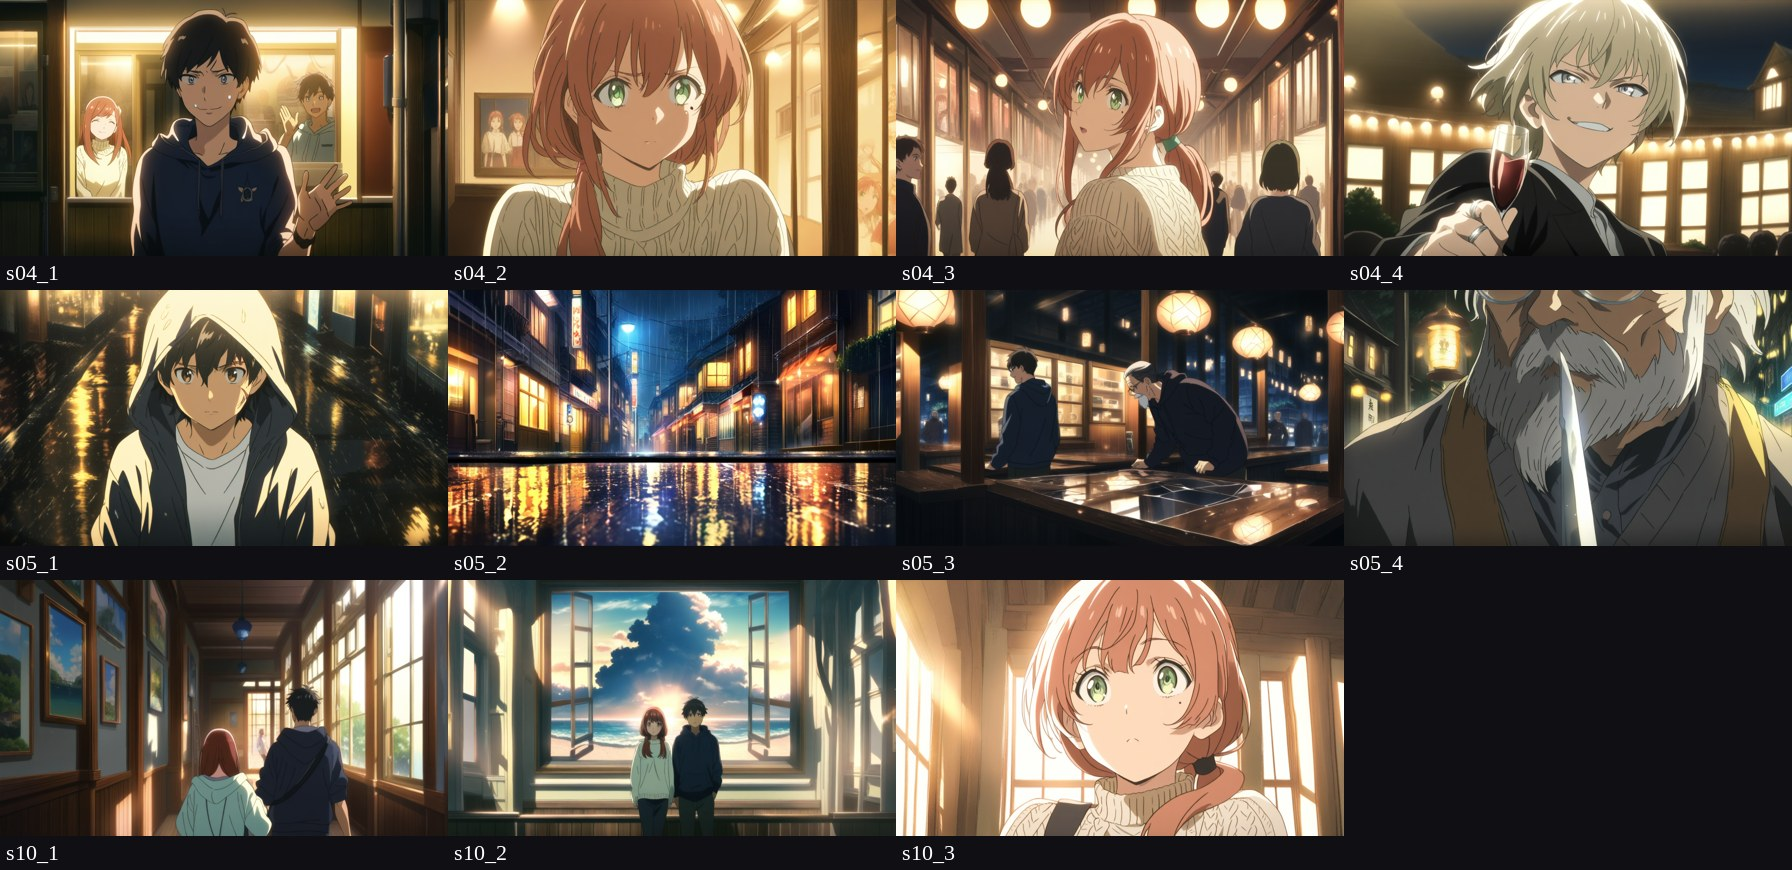

In [6]:
!python make_movie.py sheet
from IPython.display import Image, display
display(Image('output/contact_sheet.jpg'))

**Don't like a picture?** Re-roll just that shot with a new seed, then run the sheet cell again:

`!python make_movie.py images --shots s04_2 --seed 777 --overwrite`

To change what's in a shot, edit `story/scenes.json` in the dataset (or in `/kaggle/working/AnimeMovieMaker`).

## 5. Blinks, mouths and layers
First the faces, eyes and mouths are found and the characters cut out. Those models need an
older numpy than Kaggle's, so they run in their own Python 3.12 environment (a few minutes to
set up). Then both GPUs draw the closed eyes, open mouths and empty backgrounds.

In [7]:
TPY = '/tmp/tools_env/bin/python'
if not os.path.exists(TPY):
    !pip install -q uv
    !uv venv -q --python 3.12 /tmp/tools_env
if os.system(f"{TPY} -c 'import imgutils, onnxruntime' 2>/dev/null"):
    !uv pip install -q --python {TPY} dghs-imgutils onnxruntime
!{TPY} make_movie.py celplan {sc} 2>&1 | grep -v -i warn | tail -n 5
!python make_movie.py cels --gpu 0 --shard 0/2 {sc} > log_cels0.txt 2>&1 & python make_movie.py cels --gpu 1 --shard 1/2 {sc} > log_cels1.txt 2>&1 ; wait
!tail -n 4 log_cels0.txt log_cels1.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 68.6 MB/s eta 0:00:00
  [6/10] s05_3: 2 face(s), characters cover 12%
  [7/10] s05_4: 0 face(s), characters cover 81%
  [8/10] s10_1: 0 face(s), characters cover 14%
  [9/10] s10_2: 2 face(s), characters cover 8%
  [10/10] s10_3: 1 face(s), characters cover 42%
==> log_cels0.txt <==
  [2/5] s04_3: 2 face(s), background (151s)
  [3/5] s05_1: 1 face(s), background (88s)
  [4/5] s05_4: 0 face(s), no background (0s)
  [5/5] s10_2: 2 face(s), background (148s)

==> log_cels1.txt <==
  [2/5] s04_4: 1 face(s), background (47s)
  [3/5] s05_3: 2 face(s), background (156s)
  [4/5] s10_1: 0 face(s), background (27s)
  [5/5] s10_3: 1 face(s), background (94s)


## 6. Optional: AI video clips (experimental)

In [8]:
if MAKE_CLIPS:
    !python make_movie.py animate --gpu 0 --shard 0/2 {sc} > log_anim0.txt 2>&1 & python make_movie.py animate --gpu 1 --shard 1/2 {sc} > log_anim1.txt 2>&1 ; wait
    !tail -n 5 log_anim0.txt log_anim1.txt
else:
    print("Skipped. Set MAKE_CLIPS = True to try it.")

Skipped. Set MAKE_CLIPS = True to try it.


## 7. Voices
Kokoro only supports Python 3.10–3.12, so the first run sets up a separate Python 3.12 environment for it.

In [9]:
VPY = '/tmp/voice_env/bin/python'
if not os.path.exists(VPY):
    !pip install -q uv
    # --seed adds pip, which Kokoro uses to fetch its English language model on first run
    !uv venv -q --seed --python 3.12 /tmp/voice_env
if os.system(f"{VPY} -c 'import kokoro' 2>/dev/null"):
    # the transformers pin stops uv picking an ancient release that needs a Rust compiler
    !uv pip install -q --python {VPY} -r requirements-local.txt "transformers>=4.40,<5"
!{VPY} make_movie.py voices {sc}

[voices] made 0 new line(s) with 'kokoro'


## 8. Build the movie
Blinks, lip flap and layered motion are put together here (CPU, about 20–30 minutes for the whole movie).

In [10]:
!python make_movie.py assemble {sc}

[assemble] 3 scene(s), 13 segments, 1.5 min at 1920x1080
  animating 10 shot(s) from their cels
  rendered 10/13
  rendered 13/13
  ambience    0.0s-  31.6s  crowd
  ambience   30.1s-  48.6s  rain
  ambience   47.1s-  65.7s  rain_inside
  ambience   64.2s-  92.9s  room
[assemble] done: /kaggle/working/AnimeMovieMaker/output/movie.mp4  (1.5 min)


## 9. Download
Click the links. `movie_files.zip` holds the pictures, portraits, drawings and voices, so the movie can be rebuilt or re-edited on your PC.

In [11]:
import zipfile
from IPython.display import FileLink, display
with zipfile.ZipFile('/kaggle/working/movie_files.zip', 'w', zipfile.ZIP_STORED) as z:
    for folder in ['images', 'refs', 'cels', 'voices', 'clips']:
        for root, _, files in os.walk(f'output/{folder}'):
            for name in files:
                f = os.path.join(root, name)
                z.write(f, os.path.relpath(f, 'output'))
    for f in glob.glob('log_*.txt'):
        z.write(f, f'logs/{f}')
links = ['movie_files.zip']
for f in ['movie.mp4', 'movie.srt']:
    if os.path.exists(f'output/{f}'):
        shutil.copy(f'output/{f}', f'/kaggle/working/{f}')
        links.insert(0, f)
os.chdir('/kaggle/working')
for f in links:
    display(FileLink(f))

/kaggle/working/movie.srt

/kaggle/working/movie.mp4

/kaggle/working/movie_files.zip